In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
data = pd.read_csv("C:\\Users\\bingi\\Downloads\\archive (2)\\diabetes_prediction_dataset.csv")
df = data.copy()
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [3]:
df.shape

(100000, 9)

In [4]:
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 6.9 MB


In [6]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [7]:
df['smoking_history'].value_counts()

smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df.shape

(96146, 9)

<Axes: >

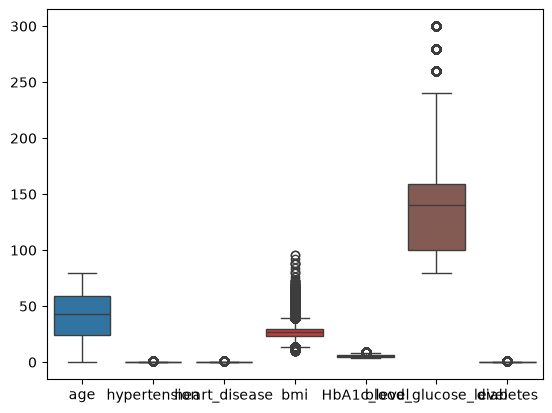

In [10]:
sns.boxplot(data = df)

In [11]:
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='str')

In [12]:
num_outlier_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

mask = pd.Series(True, index=df.index)
for col in num_outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    mask &= (df[col] >= lower_bound) & (df[col] <= upper_bound)

df_cleaned = df[mask]

<Axes: >

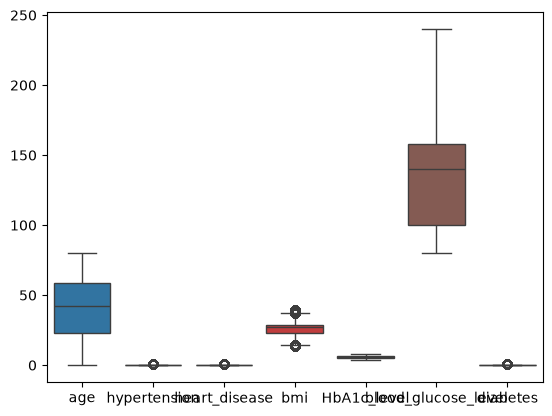

In [13]:
sns.boxplot(data = df_cleaned)

In [14]:
df_cleaned.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='str')

In [15]:
X = df_cleaned.drop(['diabetes'] , axis=1)
y = df_cleaned['diabetes']  

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler , OneHotEncoder
from sklearn.impute import SimpleImputer

num_col = X.select_dtypes(include='number').columns
cat_col = X.select_dtypes(exclude='number').columns

num_transformers = Pipeline(steps = [('imputer' , SimpleImputer(strategy='mean')),
                                     ('scaling' , StandardScaler())])

cat_transformers = Pipeline(steps=[('imputer' , SimpleImputer(strategy='most_frequent')),
                                   ('encoder' , OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(transformers=[('num' , num_transformers , num_col),
                                               ('cat' , cat_transformers , cat_col)],
                                               remainder = 'drop')

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,stratify=y
)


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = {
    'LogisticRegression' : LogisticRegression(
        C = 1.0,
        solver = 'lbfgs',
        max_iter=1000,
        class_weight='balanced'
    ),

    'Support vector machine' : SVC(
        C = 1.0,
        kernel = 'rbf',
        gamma = 'auto',
        probability=True,
        class_weight='balanced',
        max_iter=1000
    ),

    'KNeighbors' : KNeighborsClassifier(
        n_neighbors=5,
        weights = 'distance',
        metric='minkowski',
        p=2
    ),

    'Decision Tree' : DecisionTreeClassifier(
        max_depth=None,
        min_samples_split=4,
        min_samples_leaf=2,
        criterion='gini',
        max_features='sqrt',
        splitter='best',
        class_weight='balanced'
    ),

    'RandomForestClassifier' : RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=2,
        min_samples_split=4,
        max_features='sqrt',
        class_weight='balanced'
    ),

    'XGBoost' : XGBClassifier(
           n_estimators=100,       # number of boosting rounds (trees)
            learning_rate=0.2,      # shrinkage step size
            max_depth=5,            # maximum depth of each tree
            subsample=0.8,          # fraction of samples used per tree
            colsample_bytree=0.8,   # fraction of features used per tree
            gamma=0,                # minimum loss reduction for a split
            reg_alpha=0,            # L1 regularization
            reg_lambda=1,           # L2 regularization
            random_state=42,        # reproducibility
            use_label_encoder=False,
            eval_metric='logloss'
    )
}

In [20]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline

results = {}

for name, model in models.items():
    print(f'Running Model: {name}')
    
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'confusion_matrix': confusion_matrix(y_test, y_pred),
        'classification_report': classification_report(y_test, y_pred)
    }

# Neat printing
for model_name, metrics in results.items():
    print(f"\nModel: {model_name}")
    print("Accuracy:", metrics['accuracy'])
    print("Confusion Matrix:\n", metrics['confusion_matrix'])
    print("Classification Report:\n", metrics['classification_report'])


Running Model: LogisticRegression
Running Model: Support vector machine


c:\Users\bingi\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\bingi\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:337: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Running Model: KNeighbors
Running Model: Decision Tree
Running Model: RandomForestClassifier
Running Model: XGBoost


c:\Users\bingi\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:58:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Model: LogisticRegression
Accuracy: 0.8469300980781224
Confusion Matrix:
 [[14122  2593]
 [  107   817]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.84      0.91     16715
           1       0.24      0.88      0.38       924

    accuracy                           0.85     17639
   macro avg       0.62      0.86      0.64     17639
weighted avg       0.95      0.85      0.88     17639


Model: Support vector machine
Accuracy: 0.1450762514881796
Confusion Matrix:
 [[ 1635 15080]
 [    0   924]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.10      0.18     16715
           1       0.06      1.00      0.11       924

    accuracy                           0.15     17639
   macro avg       0.53      0.55      0.14     17639
weighted avg       0.95      0.15      0.17     17639


Model: KNeighbors
Accuracy: 0.9595782073813708
Confusion Matrix:
 [[16559   156]


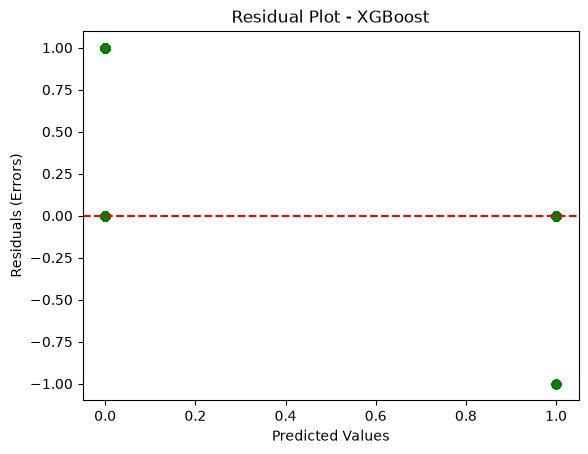

In [21]:
residuals = y_test - y_pred
plt.scatter(y_pred, residuals, color='green')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Errors)")
plt.title(f"Residual Plot - {name}")
plt.show()


In [22]:
X.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level'],
      dtype='str')

In [23]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

num_col = X.select_dtypes(include='number').columns
cat_col = X.select_dtypes(exclude='number').columns

num_transformers = Pipeline(steps = [('imputer' , SimpleImputer(strategy='mean')),
                                     ('scaling' , StandardScaler())])

cat_transformers = Pipeline(steps=[('imputer' , SimpleImputer(strategy='most_frequent')),
                                   ('encoder' , OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(transformers=[('num' , num_transformers , num_col),
                                               ('cat' , cat_transformers , cat_col)],
                                               remainder = 'drop')


model = KMeans(n_clusters=5 , init='k-means++')

cluster_pipeline = Pipeline(steps = [('preprocessor' , preprocessor) , ('clusterer' , model)])

cluster_pipeline.fit(X)

# Cluster labels
labels = cluster_pipeline['clusterer'].labels_
X['cluster'] = labels
print(X.head())

   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  cluster  
0          6.6                  140        3  
1          6.6                   80        0  
2          5.7                  158        0  
3          5.0                  155        4  
4          4.8                  155        3  


In [24]:
X_preprocessed = preprocessor.fit_transform(X)

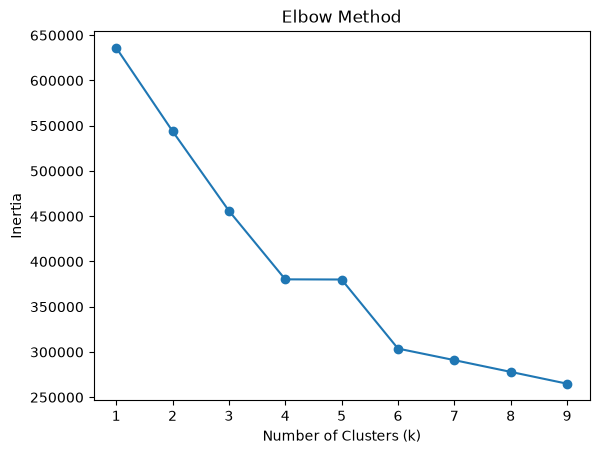

In [25]:
# for elbow method

inertia = []
for k in range(1,10):
    kmeans = KMeans(n_clusters=k , init='k-means++')
    kmeans.fit(X_preprocessed)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,10), inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()



In [26]:
X['cluster'].value_counts()

cluster
0    34588
4    24779
2    20275
1     5301
3     3252
Name: count, dtype: int64

In [27]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
import numpy as np

# Preprocess once
X_preprocessed = preprocessor.fit_transform(X)

# Sample data for silhouette (to reduce computation)
sample_size = min(1000, X_preprocessed.shape[0])
sample_idx = np.random.choice(X_preprocessed.shape[0], sample_size, replace=False)
X_sample = X_preprocessed[sample_idx]

silhouette_scores = {}
inertia = {}
K = range(2, 10)  # silhouette requires k >= 2

for k in K:
    kmeans = MiniBatchKMeans(n_clusters=k, init='k-means++', batch_size=1000, random_state=42)
    labels = kmeans.fit_predict(X_preprocessed)

    # Record inertia
    inertia[k] = kmeans.inertia_

    # Compute silhouette on sample only
    score = silhouette_score(X_sample, labels[sample_idx])
    silhouette_scores[k] = score

    print(f"k={k}, inertia={kmeans.inertia_:.0f}, silhouette score={score:.3f}")

# Best k (highest silhouette score)
best_k = max(silhouette_scores, key=silhouette_scores.get)
print(f"\nOptimal number of clusters based on silhouette score: k={best_k}")


k=2, inertia=548253, silhouette score=0.124
k=3, inertia=506004, silhouette score=0.107
k=4, inertia=427810, silhouette score=0.137
k=5, inertia=389628, silhouette score=0.151
k=6, inertia=313977, silhouette score=0.179
k=7, inertia=290977, silhouette score=0.170
k=8, inertia=280215, silhouette score=0.165
k=9, inertia=271122, silhouette score=0.156

Optimal number of clusters based on silhouette score: k=6


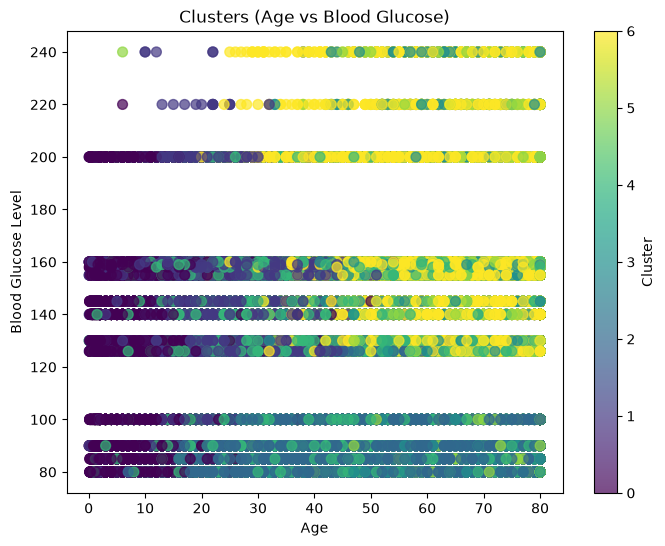

In [28]:
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans

# Preprocess once
X_preprocessed = preprocessor.fit_transform(X)

# Fit MiniBatchKMeans with k=7
kmeans = MiniBatchKMeans(n_clusters=7, batch_size=1000, random_state=42)
labels = kmeans.fit_predict(X_preprocessed)

# Attach labels back to DataFrame
X = X.copy()
X['cluster'] = labels

# Scatter plot: Age vs Blood Glucose
plt.figure(figsize=(8,6))
plt.scatter(X['age'], X['blood_glucose_level'], 
            c=X['cluster'], cmap='viridis', s=50, alpha=0.7)

plt.xlabel("Age")
plt.ylabel("Blood Glucose Level")
plt.title("Clusters (Age vs Blood Glucose)")
plt.colorbar(label='Cluster')
plt.show()


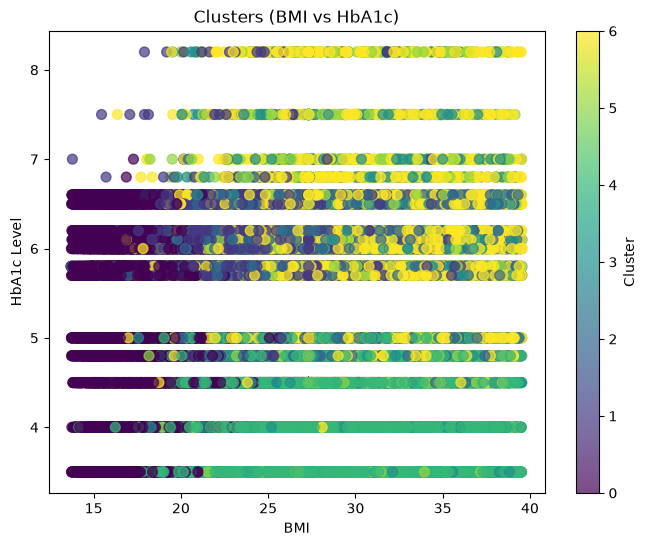

In [29]:
plt.figure(figsize=(8,6))
plt.scatter(X['bmi'], X['HbA1c_level'], 
            c=X['cluster'], cmap='viridis', s=50, alpha=0.7)

plt.xlabel("BMI")
plt.ylabel("HbA1c Level")
plt.title("Clusters (BMI vs HbA1c)")
plt.colorbar(label='Cluster')
plt.show()


In [ ]:
# Define thresholds for risk
bmi_threshold = 30              # Obesity
hba1c_threshold = 6.5           # Diabetes cutoff
glucose_threshold = 140         # High blood glucose

# Flag risky individuals
X['risk'] = (
    (X['bmi'] >= bmi_threshold) |
    (X['HbA1c_level'] >= hba1c_threshold) |
    (X['blood_glucose_level'] >= glucose_threshold)
)

# Print risky individuals
risky_people = X[X['risk'] == True]
print(risky_people[['age','bmi','HbA1c_level','blood_glucose_level','cluster']])


In [ ]:
cluster_profile = X.groupby('cluster')[['age','bmi','HbA1c_level','blood_glucose_level']].mean()
print(cluster_profile)
